In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df=pd.read_csv(r"C:\Users\NandhaKishore\Desktop\DEEP LEARNING\DAY 8\DATA SET\student_performance_interactions.csv")
df.head()

,student_id,final_score,grade,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score,parent_education_level,study_environment
0,S0001,60.137241,D,1,60.599707,61.488212,53.568119,64.972292,1.427203,75.738405,68.534371,6.809352,3.313096,65.059425,4.150025,6.104103,Master,Noisy
1,S0002,99.021977,A,1,92.289287,85.612565,91.873759,89.040461,4.813612,89.602736,91.990197,5.567793,4.925359,76.016617,8.714693,1.982358,High School,Quiet
2,S0003,70.522955,C,1,80.259667,82.160656,72.736065,74.243663,1.240908,81.495426,69.669666,6.702875,5.107888,113.616872,5.928220,4.463662,High School,Moderate
3,S0004,63.448537,D,1,72.926217,75.979145,76.726496,67.715995,2.190601,71.472047,71.976757,7.854439,3.772446,108.686690,4.224928,4.740474,High School,Noisy
4,S0005,66.483019,C,1,48.581025,51.379977,48.993224,46.145011,2.192265,64.276582,68.940591,7.662429,1.898989,42.107294,9.506815,1.143852,Master,Quiet


In [3]:
X = df[[
    'previous_score',
    'math_prev_score',
    'science_prev_score',
    'language_prev_score',
    'daily_study_hours',
    'attendance_percentage',
    'homework_completion_rate',
    'sleep_hours',
    'screen_time_hours',
    'physical_activity_minutes',
    'motivation_score',
    'exam_anxiety_score'
]]

y = df['pass_fail']

print("\nInput Shape :", X.shape)
print("Output Shape :", y.shape)


Input Shape : (1000, 12)
Output Shape : (1000,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
# WITHOUT EARLY STOPPING

model1 = Sequential()

model1.add(Dense(64, activation='relu',
                 input_shape=(X_train.shape[1],)))

model1.add(Dense(32, activation='relu'))
model1.add(Dense(16, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_without_es = model1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9156 - loss: 0.4532 - val_accuracy: 0.9250 - val_loss: 0.3334
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9328 - loss: 0.2544 - val_accuracy: 0.9250 - val_loss: 0.2310
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9328 - loss: 0.1990 - val_accuracy: 0.9250 - val_loss: 0.2032
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9328 - loss: 0.1766 - val_accuracy: 0.9250 - val_loss: 0.1847
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9328 - loss: 0.1618 - val_accuracy: 0.9250 - val_loss: 0.1725
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9328 - loss: 0.1513 - val_accuracy: 0.9250 - val_loss: 0.1646
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9328 - loss: 0.1447 - val_accuracy: 0.9250 - val_loss: 0.1593
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9328 - loss: 0.1394 - val_accuracy: 0.9250 - val_loss

In [39]:
# WITH EARLY STOPPING

model2 = Sequential()

model2.add(Dense(64, activation='relu',
                 input_shape=(X_train.shape[1],)))

model2.add(Dense(32, activation='relu'))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_with_es = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8906 - loss: 0.5410 - val_accuracy: 0.9250 - val_loss: 0.4326
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9328 - loss: 0.3280 - val_accuracy: 0.9250 - val_loss: 0.2697
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9328 - loss: 0.2206 - val_accuracy: 0.9250 - val_loss: 0.2028
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9328 - loss: 0.1770 - val_accuracy: 0.9250 - val_loss: 0.1775
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9328 - loss: 0.1587 - val_accuracy: 0.9250 - val_loss: 0.1648
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9328 - loss: 0.1472 - val_accuracy: 0.9250 - val_loss: 0.1552
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9328 - loss: 0.1389 - val_accuracy: 0.9375 - val_loss: 0.1500
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9359 - loss: 0.1334 - val_accuracy: 0.9312 - val_loss

In [40]:
loss1, acc1 = model1.evaluate(X_test, y_test)

loss2, acc2 = model2.evaluate(X_test, y_test)

print("\n===================================")
print("WITHOUT EARLY STOPPING")
print("===================================")

print("Test Accuracy :", acc1)
print("Test Loss :", loss1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - loss: 0.1445 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9650 - loss: 0.1186 

WITHOUT EARLY STOPPING
Test Accuracy : 0.949999988079071
Test Loss : 0.1444532573223114


In [41]:
print("\n===================================")
print("WITH EARLY STOPPING")
print("===================================")

print("Test Accuracy :", acc2)
print("Test Loss :", loss2)




WITH EARLY STOPPING
Test Accuracy : 0.9649999737739563
Test Loss : 0.11864592880010605


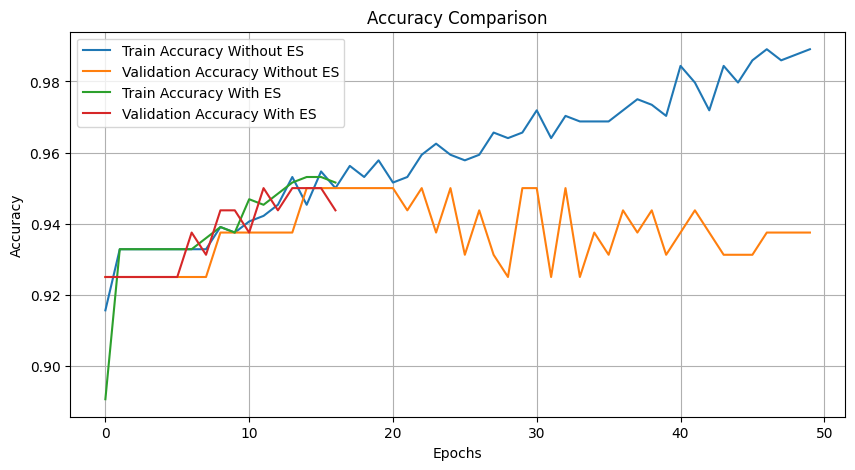

In [42]:
# =========================================================
# ACCURACY GRAPH
# =========================================================

plt.figure(figsize=(10,5))

# Without ES
plt.plot(
    history_without_es.history['accuracy'],
    label='Train Accuracy Without ES'
)

plt.plot(
    history_without_es.history['val_accuracy'],
    label='Validation Accuracy Without ES'
)

# With ES
plt.plot(
    history_with_es.history['accuracy'],
    label='Train Accuracy With ES'
)

plt.plot(
    history_with_es.history['val_accuracy'],
    label='Validation Accuracy With ES'
)

plt.title("Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()


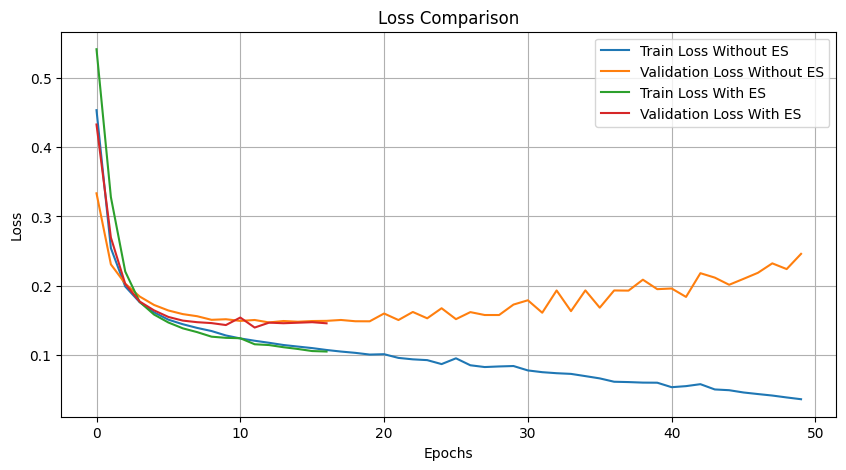

In [43]:
# =========================================================
# LOSS GRAPH
# =========================================================

plt.figure(figsize=(10,5))

# Without ES
plt.plot(
    history_without_es.history['loss'],
    label='Train Loss Without ES'
)

plt.plot(
    history_without_es.history['val_loss'],
    label='Validation Loss Without ES'
)

# With ES
plt.plot(
    history_with_es.history['loss'],
    label='Train Loss With ES'
)

plt.plot(
    history_with_es.history['val_loss'],
    label='Validation Loss With ES'
)

plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()


In [44]:
model1.save("model1.h5")
model2.save("model2.h5")
import joblib
joblib.dump(scaler, "scaler.pkl")
print("Files saved successfully")

Files saved successfully


In [45]:
import joblib
from tensorflow.keras.models import load_model

model1 = load_model("model1.h5")
model2 = load_model("model2.h5")

scaler = joblib.load("scaler.pkl")

print("Loaded successfully")

Loaded successfully
